In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_parquet("/content/drive/MyDrive/ERP/df_merged_3M.parquet")

In [5]:
df

,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,Diastolic Blood Pressure,...,tfidf_90,tfidf_91,tfidf_92,tfidf_93,tfidf_94,tfidf_95,tfidf_96,tfidf_97,tfidf_98,tfidf_99
0,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
1,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,1.539497,0.076552,-0.210975,0.473340,4.330931,2.345726,-0.446205,8.077132,-0.251045,0.299629
2,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,0.736311,1.742810,-0.210975,-0.449029,-0.370967,-0.358055,0.580470,-0.429672,-0.251045,0.656316
3,6.0646,1,77.0,86.0,98.0,17.0,36.933333,79.041667,115.125000,61.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,1.014802
4,6.0646,1,77.0,84.0,100.0,18.0,36.800000,78.458333,117.375000,59.000000,...,0.494767,1.278629,-0.210975,0.875740,3.005628,-0.358055,-0.446205,0.927890,-0.251045,-0.724288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2178062,1.1242,0,64.0,101.0,97.0,20.0,36.982697,92.501582,118.283516,79.610615,...,1.224191,0.246046,-0.210975,0.716871,-0.370967,4.768429,-0.446205,0.765088,-0.251045,-0.724288
2178063,1.1242,0,64.0,94.0,97.0,15.0,37.030493,91.407209,115.528930,79.346348,...,1.224191,0.246046,-0.210975,0.716871,-0.370967,4.768429,-0.446205,0.765088,-0.251045,-0.724288
2178064,1.1242,0,64.0,100.0,97.0,21.0,36.587685,81.650256,92.062569,76.444099,...,1.485180,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
2178065,1.1242,0,64.0,100.0,97.0,21.0,36.587685,81.650256,92.062569,76.444099,...,0.872858,0.077255,-0.210975,0.474349,2.767061,3.702053,-0.065075,0.516563,-0.251045,-0.724288


In [6]:
import numpy as np
import pandas as pd


tfidf_cols = [c for c in df.columns if c.startswith("tfidf_")]
X = df[tfidf_cols]
A = X.to_numpy()

# 1) Overall density (fraction of non-zeros)
density = np.count_nonzero(A) / A.size
print(f"Overall density: {density:.3f}")   # >0.20 ⇒ not very sparse

# 2) Per-feature non-zero fraction (how often each term appears)
feat_density = (A != 0).mean(axis=0)
s = pd.Series(feat_density, index=tfidf_cols).sort_values()
print(s.head(10))      # sparsest features
print(s.tail(10))      # densest features

# 3) Per-row non-zero count (how many TF-IDF terms per sample)
row_nnz = (A != 0).sum(axis=1)
print(pd.Series(row_nnz).describe())

# 4) Check for signs of z-scoring (which destroys sparsity)
col_stats = X.agg(['mean','std','min','max']).T
print(col_stats.head())



Overall density: 1.000
tfidf_0    1.0
tfidf_1    1.0
tfidf_2    1.0
tfidf_3    1.0
tfidf_4    1.0
tfidf_5    1.0
tfidf_6    1.0
tfidf_7    1.0
tfidf_8    1.0
tfidf_9    1.0
dtype: float64
tfidf_90    1.0
tfidf_91    1.0
tfidf_92    1.0
tfidf_93    1.0
tfidf_94    1.0
tfidf_95    1.0
tfidf_96    1.0
tfidf_97    1.0
tfidf_98    1.0
tfidf_99    1.0
dtype: float64
count    2178067.0
mean         100.0
std            0.0
min          100.0
25%          100.0
50%          100.0
75%          100.0
max          100.0
dtype: float64
             mean       std       min        max
tfidf_0 -0.013004  0.978462 -0.520320   9.103677
tfidf_1  0.100010  1.093645 -0.447449  16.052897
tfidf_2 -0.017964  0.987995 -0.442609   9.007375
tfidf_3  0.004346  0.990438 -0.486031   8.992004
tfidf_4 -0.012460  0.960734 -0.316164  15.199968


In [7]:
from sklearn.preprocessing import LabelEncoder

# List the columns you want to encode
cols_to_encode = ['CATEGORY', 'DESCRIPTION']

# Create a dictionary to store the encoders for each column (useful for inverse transforming later)
encoders = {}

for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # Save the encoder


In [8]:
df

,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,Diastolic Blood Pressure,...,tfidf_90,tfidf_91,tfidf_92,tfidf_93,tfidf_94,tfidf_95,tfidf_96,tfidf_97,tfidf_98,tfidf_99
0,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
1,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,1.539497,0.076552,-0.210975,0.473340,4.330931,2.345726,-0.446205,8.077132,-0.251045,0.299629
2,6.0646,1,77.0,88.0,98.0,9.0,37.000000,78.000000,114.000000,62.000000,...,0.736311,1.742810,-0.210975,-0.449029,-0.370967,-0.358055,0.580470,-0.429672,-0.251045,0.656316
3,6.0646,1,77.0,86.0,98.0,17.0,36.933333,79.041667,115.125000,61.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,1.014802
4,6.0646,1,77.0,84.0,100.0,18.0,36.800000,78.458333,117.375000,59.000000,...,0.494767,1.278629,-0.210975,0.875740,3.005628,-0.358055,-0.446205,0.927890,-0.251045,-0.724288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2178062,1.1242,0,64.0,101.0,97.0,20.0,36.982697,92.501582,118.283516,79.610615,...,1.224191,0.246046,-0.210975,0.716871,-0.370967,4.768429,-0.446205,0.765088,-0.251045,-0.724288
2178063,1.1242,0,64.0,94.0,97.0,15.0,37.030493,91.407209,115.528930,79.346348,...,1.224191,0.246046,-0.210975,0.716871,-0.370967,4.768429,-0.446205,0.765088,-0.251045,-0.724288
2178064,1.1242,0,64.0,100.0,97.0,21.0,36.587685,81.650256,92.062569,76.444099,...,1.485180,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
2178065,1.1242,0,64.0,100.0,97.0,21.0,36.587685,81.650256,92.062569,76.444099,...,0.872858,0.077255,-0.210975,0.474349,2.767061,3.702053,-0.065075,0.516563,-0.251045,-0.724288


In [9]:
print(list(df.columns))

['LOS', 'GENDER', 'AGE', 'Heart Rate', 'O2 Saturation', 'Respiratory Rate', 'Temperature (C)', 'Mean Blood Pressure', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'WBC', 'pH', 'Glucose', 'Sodium', 'Potassium', 'Creatinine', 'BUN', 'Hematocrit', 'Height', 'Weight', 'GCS Total', 'Lactic Acid', 'FiO2', 'PaO2', 'ADMISSION_TYPE', 'INSURANCE', 'HOSPITAL_EXPIRE_FLAG', 'CATEGORY', 'DESCRIPTION', 'TEXT', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', '

In [10]:
df = df.sample(frac=0.5, random_state=42).reset_index(drop=True)

In [11]:
X = df.drop(["HOSPITAL_EXPIRE_FLAG",'TEXT'], axis = 1)
y = df["HOSPITAL_EXPIRE_FLAG"]

In [12]:
X

,LOS,GENDER,AGE,Heart Rate,O2 Saturation,Respiratory Rate,Temperature (C),Mean Blood Pressure,Systolic Blood Pressure,Diastolic Blood Pressure,...,tfidf_90,tfidf_91,tfidf_92,tfidf_93,tfidf_94,tfidf_95,tfidf_96,tfidf_97,tfidf_98,tfidf_99
0,3.9072,1,20.0,79.0,97.0,18.0,37.038900,87.405557,106.519462,77.848605,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,1.702164,-0.429672,-0.251045,2.164695
1,10.0056,1,75.0,83.0,98.0,21.0,36.561811,127.000000,180.000000,95.000000,...,-0.464806,0.305840,-0.210975,-0.449029,-0.370967,-0.358055,5.754125,-0.429672,-0.251045,0.665344
2,16.5928,1,23.0,99.0,97.0,23.5,36.567361,79.189092,95.974665,70.796305,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,1.291491,-0.429672,-0.251045,-0.724288
3,2.6349,1,22.0,88.0,97.0,17.0,36.831418,84.159510,107.210201,72.634164,...,0.863004,0.391480,-0.210975,-0.449029,-0.370967,-0.358055,-0.067883,1.918489,-0.251045,0.293198
4,7.2556,1,69.0,79.0,100.0,7.5,36.651454,68.000000,99.000000,53.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089029,7.1539,1,64.0,85.0,97.0,20.0,36.622733,87.435748,108.532784,76.887230,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
1089030,4.8994,0,73.0,95.0,97.0,17.0,36.724828,84.650947,99.451922,77.250459,...,-0.464806,1.153954,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
1089031,0.9497,0,73.0,72.0,97.0,16.0,36.651053,91.016279,117.663842,77.692497,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,-0.724288
1089032,51.6403,1,81.0,88.0,99.0,12.0,36.748004,69.000000,102.000000,57.000000,...,-0.464806,-0.565398,-0.210975,-0.449029,-0.370967,-0.358055,-0.446205,-0.429672,-0.251045,0.345074


In [13]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len - 1])
    return np.stack(Xs), np.array(ys)

seq_len = 5
X_seq, y_seq = create_sequences(X, y, seq_len)
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)


In [14]:
from sklearn.preprocessing import StandardScaler

# Flatten for scaling
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_test_flat  = X_test.reshape(-1, X_test.shape[-1])

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_test_scaled_flat  = scaler.transform(X_test_flat)

# Restore 3D shape
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_test_scaled  = X_test_scaled_flat.reshape(X_test.shape)


In [15]:
train_ds = TensorDataset(torch.from_numpy(X_train_scaled).float(), torch.from_numpy(y_train).float()) #turn numpy array into tensor
test_ds = TensorDataset(torch.from_numpy(X_test_scaled).float(), torch.from_numpy(y_test).float())
train_loader = DataLoader(train_ds, batch_size = 1024, shuffle=True, pin_memory=True, num_workers=8)
test_loader   = DataLoader(test_ds,   batch_size = 1024, pin_memory=True, num_workers=8)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU available:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU available: NVIDIA A100-SXM4-40GB


In [17]:
import numpy as np

# Suppose y_train is your array of labels (0 for negative, 1 for positive)
negatives = np.sum(y_train == 0)
positives = np.sum(y_train == 1)

print("Number of negative samples:", negatives)
print("Number of positive samples:", positives)

Number of negative samples: 733541
Number of positive samples: 137683


## **LSTM**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch, seq_len, input_dim]
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]               # last time-step
        return self.fc(out).squeeze(-1)   # [batch]

# ----- your existing setup (assumes X_train, train_loader, test_loader, device already defined) -----
input_dim  = X_train.shape[2]
hidden_dim = 256
num_layers = 4

model = LSTMClassifier(input_dim, hidden_dim, num_layers).to(device)

pos_weight = torch.tensor([2.0], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=2e-4)

num_epochs = 100

# ---- NEW: trackers for curves ----
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, num_epochs + 1):
    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        logits = model(x)
        loss  = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs       = torch.sigmoid(logits)
            batch_preds = (probs > 0.5).float()
            running_correct += (batch_preds.int() == y.int()).sum().item()
            total_samples   += bs

    avg_train_loss = running_loss / total_samples
    train_acc = running_correct / total_samples

    # ---------- TEST / EVAL ----------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            logits = model(xb)
            loss = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds.int() == yb.int()).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / test_total
    test_acc = test_running_correct / test_total

    # ---- NEW: store metrics for plotting ----
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test  Loss: {avg_test_loss:.4f} Acc: {test_acc:.3f}")

# ---------- Final test metrics ----------
model.eval()
all_preds_LSTM, all_probs_LSTM, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()
        probs_LSTM  = torch.sigmoid(logits)
        preds_LSTM  = (probs_LSTM > 0.5).int()

        all_preds_LSTM.extend(preds_LSTM.numpy())
        all_probs_LSTM.extend(probs_LSTM.numpy())
        all_labels.extend(yb.numpy())

acc_LSTM = accuracy_score(all_labels, all_preds_LSTM)
auc_LSTM = roc_auc_score(all_labels, all_probs_LSTM)
print(f"Test — Accuracy: {acc_LSTM:.4f} | AUC: {auc_LSTM:.4f}")

Epoch   1 | Train Loss: 0.5393 Acc: 0.840 | Test  Loss: 0.5023 Acc: 0.856
Epoch   2 | Train Loss: 0.4947 Acc: 0.847 | Test  Loss: 0.4817 Acc: 0.853
Epoch   3 | Train Loss: 0.4792 Acc: 0.851 | Test  Loss: 0.4719 Acc: 0.852
Epoch   4 | Train Loss: 0.4681 Acc: 0.855 | Test  Loss: 0.4635 Acc: 0.845
Epoch   5 | Train Loss: 0.4593 Acc: 0.857 | Test  Loss: 0.4572 Acc: 0.867
Epoch   6 | Train Loss: 0.4509 Acc: 0.860 | Test  Loss: 0.4490 Acc: 0.857
Epoch   7 | Train Loss: 0.4448 Acc: 0.862 | Test  Loss: 0.4487 Acc: 0.854
Epoch   8 | Train Loss: 0.4389 Acc: 0.864 | Test  Loss: 0.4380 Acc: 0.867
Epoch   9 | Train Loss: 0.4328 Acc: 0.866 | Test  Loss: 0.4357 Acc: 0.873
Epoch  10 | Train Loss: 0.4291 Acc: 0.867 | Test  Loss: 0.4301 Acc: 0.872
Epoch  11 | Train Loss: 0.4256 Acc: 0.868 | Test  Loss: 0.4258 Acc: 0.868
Epoch  12 | Train Loss: 0.4224 Acc: 0.869 | Test  Loss: 0.4236 Acc: 0.874
Epoch  13 | Train Loss: 0.4185 Acc: 0.871 | Test  Loss: 0.4200 Acc: 0.871
Epoch  14 | Train Loss: 0.4160 Acc: 0.

In [ ]:
from sklearn.metrics import classification_report

report_LSTM = classification_report(all_labels, all_preds_LSTM, digits=4)
print(report_LSTM)


              precision    recall  f1-score   support

         0.0     0.9303    0.9398    0.9350    183536
         1.0     0.6587    0.6228    0.6403     34270

    accuracy                         0.8899    217806
   macro avg     0.7945    0.7813    0.7876    217806
weighted avg     0.8876    0.8899    0.8886    217806



In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa_LSTM = cohen_kappa_score(all_labels, all_preds_LSTM)
print(f"Cohen’s kappa for LSTM: {kappa_LSTM:.3f}")

Cohen’s kappa for LSTM: 0.575


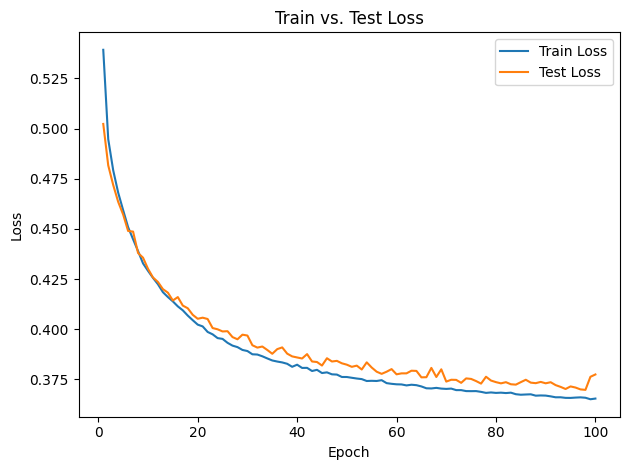

In [ ]:
epochs = np.arange(1, num_epochs + 1)

# Loss curves
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss')
plt.legend()
plt.tight_layout()
plt.show()

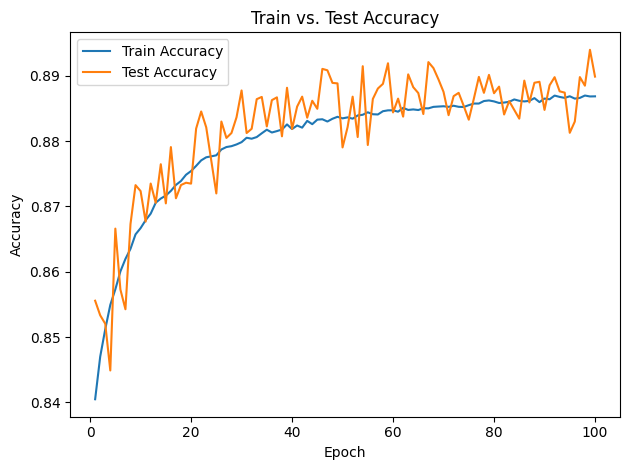

In [ ]:
# Accuracy curves
plt.figure()
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

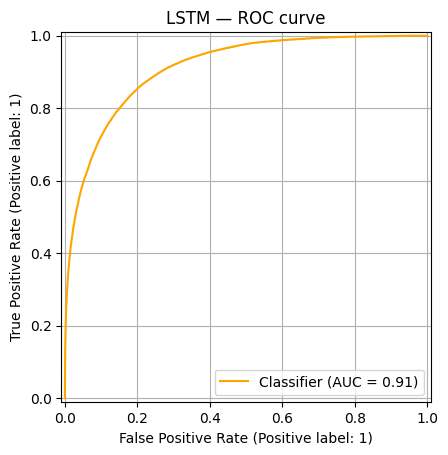

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("LSTM — ROC curve")
plt.grid(True); plt.show()

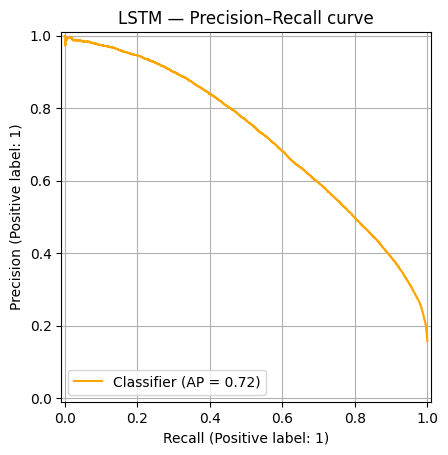

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("LSTM — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for LSTM')

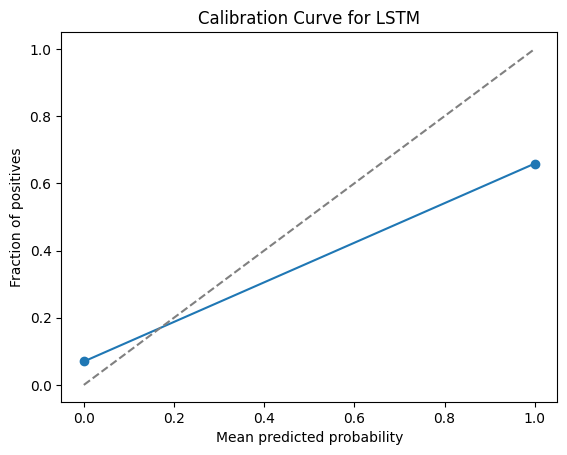

In [ ]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_LSTM, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for LSTM')

Text(0.5, 1.0, 'Normalized Confustion Matrix for LSTM')

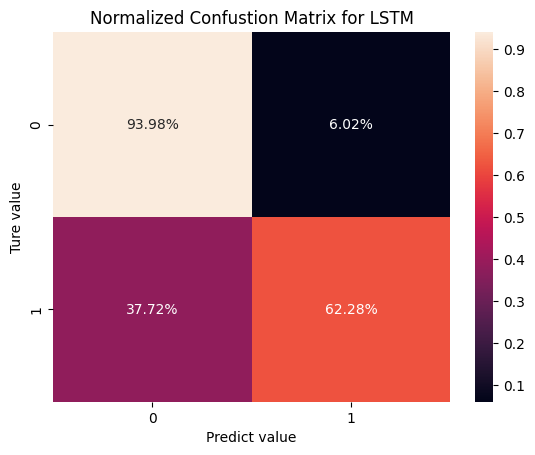

In [ ]:
from sklearn.metrics import confusion_matrix

CM_LSTM = confusion_matrix(all_labels, all_preds_LSTM, normalize = 'true')
sns.heatmap(CM_LSTM, annot= True, fmt ='.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for LSTM")

# **LSTM - Fine Tune**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterGrid

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initialize hidden + cell states
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size,
                         device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        # Take last time-step
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)


def train_and_evaluate(hidden_dim, num_layers, lr, dropout, weight_decay):

    model = LSTMClassifier(
        input_dim=X_seq.shape[2],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    pos_weight = torch.tensor([negatives / positives], device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for epoch in range(3):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            preds  = model(xb)
            loss   = criterion(preds, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb).cpu())
            all_probs .extend(probs.numpy())
            all_labels.extend(yb.numpy())

    return roc_auc_score(all_labels, all_probs)


param_grid = {
    "hidden_dim":   [64, 128, 256, 512],
    "num_layers":   [2, 3, 4],
    "lr":           [1e-3, 1e-4],
    "dropout":      [0.1, 0.2, 0.3],
    "weight_decay": [1e-4, 2e-4, 3e-4],
}

if __name__ == "__main__":
    best_score = 0.0
    best_params = None

    for params in ParameterGrid(param_grid):
        auc = train_and_evaluate(**params)
        print(f"{params} → AUC={auc:.4f}")
        if auc > best_score:
            best_score, best_params = auc, params

    print("\nBest hyperparameters:")
    print(best_params)
    print(f"Best AUC = {best_score:.4f}")


{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'weight_decay': 0.0001} → AUC=0.8583
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'weight_decay': 0.0002} → AUC=0.8547
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 2, 'weight_decay': 0.0003} → AUC=0.8544
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 3, 'weight_decay': 0.0001} → AUC=0.8571
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 3, 'weight_decay': 0.0002} → AUC=0.8553
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 3, 'weight_decay': 0.0003} → AUC=0.8547
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4, 'weight_decay': 0.0001} → AUC=0.8571
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4, 'weight_decay': 0.0002} → AUC=0.8552
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4, 'weight_decay': 0.0003} → AUC=0.5000
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.0001, 'num_layers': 2, 'weight_decay': 

In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)

input_dim  = X_train.shape[2]
hidden_dim = 512
num_layers = 3
dropout    = 0.1

model = LSTMClassifier(input_dim, hidden_dim, num_layers, dropout).to(device)
pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 100

# ---- NEW: trackers for plotting ----
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        logits = model(x)
        loss   = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs       = torch.sigmoid(logits)
            batch_preds = (probs > 0.5).float()
            running_correct += (batch_preds.int() == y.int()).sum().item()
            total_samples   += bs

    avg_train_loss = running_loss / total_samples          # use actual seen samples
    train_acc      = running_correct / total_samples

    # -------- TEST / VAL --------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            logits = model(xb)
            loss   = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds.int() == yb.int()).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / test_total         # use actual seen samples
    test_acc      = test_running_correct / test_total

    # ---- store for plots ----
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {avg_test_loss:.4f} Acc: {test_acc:.3f}")

# -------- Final test metrics (as before) --------
model.eval()
all_preds_LSTM, all_probs_LSTM, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()
        probs_LSTM  = torch.sigmoid(logits)
        preds_LSTM  = (probs_LSTM > 0.5).int()

        all_preds_LSTM.extend(preds_LSTM.numpy())
        all_probs_LSTM.extend(probs_LSTM.numpy())
        all_labels.extend(yb.numpy())

acc_LSTM = accuracy_score(all_labels, all_preds_LSTM)
auc_LSTM = roc_auc_score(all_labels, all_probs_LSTM)
print(f"Test — Accuracy: {acc_LSTM:.4f} | AUC: {auc_LSTM:.4f}")

Epoch   1 | Train Loss: 0.8890 Acc: 0.706 | Test Loss: 0.8366 Acc: 0.733
Epoch   2 | Train Loss: 0.8196 Acc: 0.737 | Test Loss: 0.8037 Acc: 0.760
Epoch   3 | Train Loss: 0.7753 Acc: 0.755 | Test Loss: 0.7672 Acc: 0.750
Epoch   4 | Train Loss: 0.7364 Acc: 0.770 | Test Loss: 0.7398 Acc: 0.770
Epoch   5 | Train Loss: 0.7002 Acc: 0.783 | Test Loss: 0.7195 Acc: 0.776
Epoch   6 | Train Loss: 0.6675 Acc: 0.794 | Test Loss: 0.7169 Acc: 0.764
Epoch   7 | Train Loss: 0.6394 Acc: 0.804 | Test Loss: 0.6834 Acc: 0.801
Epoch   8 | Train Loss: 0.6140 Acc: 0.812 | Test Loss: 0.6783 Acc: 0.798
Epoch   9 | Train Loss: 0.5908 Acc: 0.820 | Test Loss: 0.6753 Acc: 0.810
Epoch  10 | Train Loss: 0.5712 Acc: 0.825 | Test Loss: 0.6787 Acc: 0.824
Epoch  11 | Train Loss: 0.5517 Acc: 0.832 | Test Loss: 0.6661 Acc: 0.805
Epoch  12 | Train Loss: 0.5335 Acc: 0.837 | Test Loss: 0.6686 Acc: 0.813
Epoch  13 | Train Loss: 0.5189 Acc: 0.842 | Test Loss: 0.6730 Acc: 0.828
Epoch  14 | Train Loss: 0.5046 Acc: 0.846 | Test Lo

In [30]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_LSTM = classification_report(all_labels, all_preds_LSTM, digits=4)
print(report_LSTM)


              precision    recall  f1-score   support

         0.0     0.9491    0.8854    0.9161    183536
         1.0     0.5484    0.7456    0.6320     34270

    accuracy                         0.8634    217806
   macro avg     0.7487    0.8155    0.7740    217806
weighted avg     0.8860    0.8634    0.8714    217806



In [31]:
from sklearn.metrics import cohen_kappa_score

kappa_LSTM = cohen_kappa_score(all_labels, all_preds_LSTM)
print(f"Cohen’s kappa for LSTM: {kappa_LSTM:.3f}")

Cohen’s kappa for LSTM: 0.550


Loss

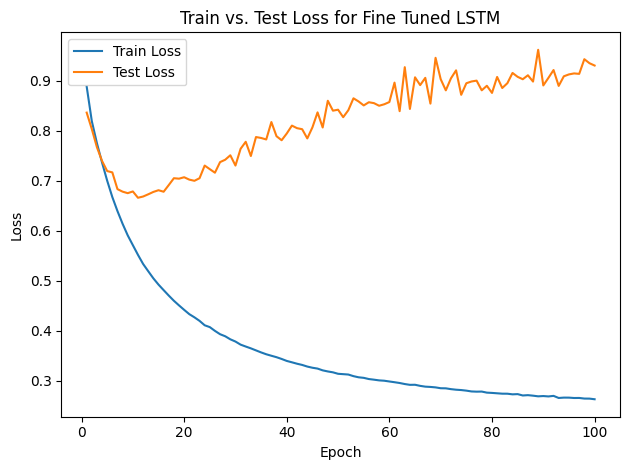

In [23]:
epochs = np.arange(1, num_epochs + 1)

# Loss
import matplotlib.pyplot as plt
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss for Fine Tuned LSTM')
plt.legend()
plt.tight_layout()
plt.show()

Accuracy Rate

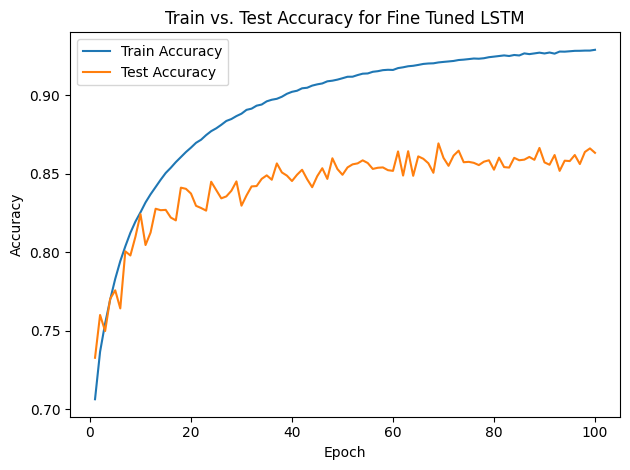

In [24]:
# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy for Fine Tuned LSTM')
plt.legend()
plt.tight_layout()
plt.show()

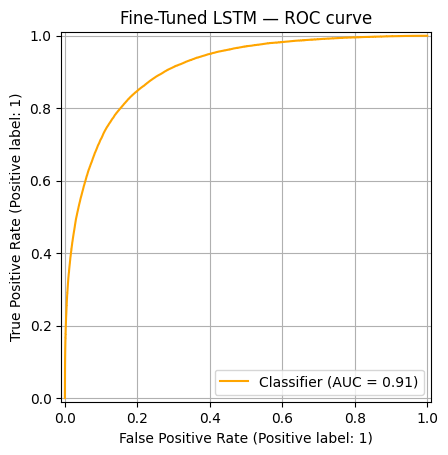

In [25]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("Fine-Tuned LSTM — ROC curve")
plt.grid(True); plt.show()

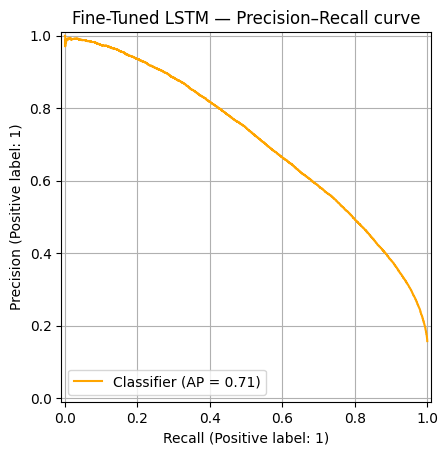

In [26]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_LSTM, color = "orange")
plt.title("Fine-Tuned LSTM — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for LSTM')

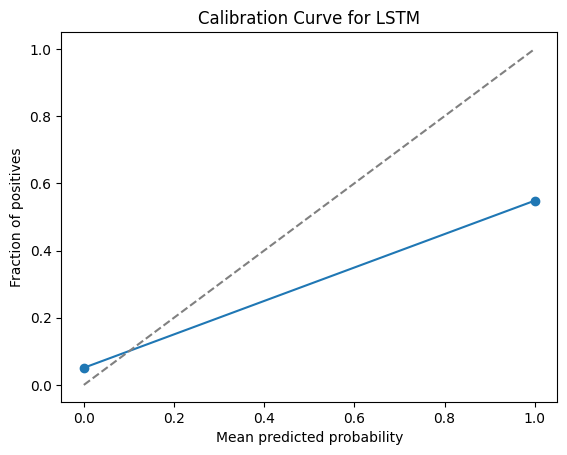

In [27]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_LSTM, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for LSTM')

Text(0.5, 1.0, 'Normalized Confustion Matrix for Fine Tuned LSTM')

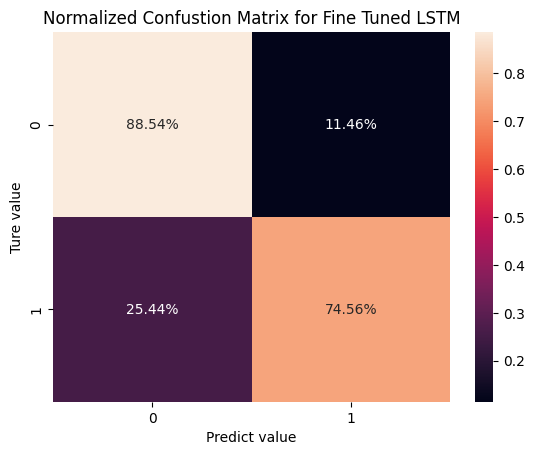

In [28]:
from sklearn.metrics import confusion_matrix

CM_LSTM = confusion_matrix(all_labels, all_preds_LSTM, normalize = 'true')
sns.heatmap(CM_LSTM, annot= True, fmt ='.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for Fine Tuned LSTM")

# **GRU**

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim=1):
        super().__init__()
        self.GRU = nn.GRU(
            input_dim, hidden_dim, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.GRU(x)          # [B, T, H]
        out = out[:, -1, :]           # last time step
        out = self.fc(out)            # [B, 1]
        return out

input_dim  = X_train.shape[2]
hidden_dim = 512
num_layers = 3
dropout    = 0.2

model = GRUModel(input_dim, hidden_dim, num_layers, dropout).to(device)

pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1.5e-4)

num_epochs = 100

# ---- NEW: trackers ----
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float().unsqueeze(-1)  # [B,1]

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            running_correct += (preds == y).sum().item()
            total_samples += bs

    avg_train_loss = running_loss / total_samples        # FIX: use seen samples
    train_acc      = running_correct / total_samples

    # -------- TEST / VALIDATION --------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float().unsqueeze(-1)

            logits = model(xb)
            loss   = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds == yb).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / test_total       # FIX: use seen samples
    test_acc      = test_running_correct / test_total

    # ---- store for plots ----
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {avg_test_loss:.4f} Acc: {test_acc:.3f}")

# -------- Final test metrics (AUC & accuracy) --------
model.eval()
all_preds_GRU, all_probs_GRU, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()                      # [B,1]
        probs_GRU  = torch.sigmoid(logits)            # [B,1]
        preds_GRU  = (probs_GRU > 0.5).int()          # [B,1]

        all_preds_GRU.extend(preds_GRU.numpy().ravel())
        all_probs_GRU.extend(probs_GRU.numpy().ravel())
        all_labels.extend(yb.cpu().numpy().ravel())   # ensure 1D arrays

acc = accuracy_score(all_labels, all_preds_GRU)
auc = roc_auc_score(all_labels, all_probs_GRU)
print(f"Test — Accuracy: {acc:.4f} | AUC: {auc:.4f}")

Epoch   1 | Train Loss: 0.9085 Acc: 0.698 | Test Loss: 0.8655 Acc: 0.719
Epoch   2 | Train Loss: 0.8576 Acc: 0.720 | Test Loss: 0.8399 Acc: 0.699
Epoch   3 | Train Loss: 0.8329 Acc: 0.728 | Test Loss: 0.8200 Acc: 0.719
Epoch   4 | Train Loss: 0.8128 Acc: 0.735 | Test Loss: 0.8031 Acc: 0.736
Epoch   5 | Train Loss: 0.7962 Acc: 0.741 | Test Loss: 0.7967 Acc: 0.769
Epoch   6 | Train Loss: 0.7826 Acc: 0.746 | Test Loss: 0.7796 Acc: 0.730
Epoch   7 | Train Loss: 0.7693 Acc: 0.751 | Test Loss: 0.7747 Acc: 0.729
Epoch   8 | Train Loss: 0.7593 Acc: 0.755 | Test Loss: 0.7612 Acc: 0.750
Epoch   9 | Train Loss: 0.7487 Acc: 0.758 | Test Loss: 0.7565 Acc: 0.748
Epoch  10 | Train Loss: 0.7382 Acc: 0.761 | Test Loss: 0.7478 Acc: 0.767
Epoch  11 | Train Loss: 0.7289 Acc: 0.765 | Test Loss: 0.7472 Acc: 0.761
Epoch  12 | Train Loss: 0.7205 Acc: 0.768 | Test Loss: 0.7386 Acc: 0.776
Epoch  13 | Train Loss: 0.7126 Acc: 0.770 | Test Loss: 0.7339 Acc: 0.760
Epoch  14 | Train Loss: 0.7057 Acc: 0.774 | Test Lo

In [ ]:
from sklearn.metrics import classification_report

report_GRU = classification_report(all_labels, all_preds_GRU, digits=4)
print(report_GRU)


              precision    recall  f1-score   support

         0.0     0.9528    0.7977    0.8684    183536
         1.0     0.4211    0.7884    0.5490     34270

    accuracy                         0.7962    217806
   macro avg     0.6870    0.7930    0.7087    217806
weighted avg     0.8691    0.7962    0.8181    217806



In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa_GRU = cohen_kappa_score(all_labels, all_preds_GRU)
print(f"Cohen’s kappa: {kappa_GRU:.3f}")

Cohen’s kappa: 0.433


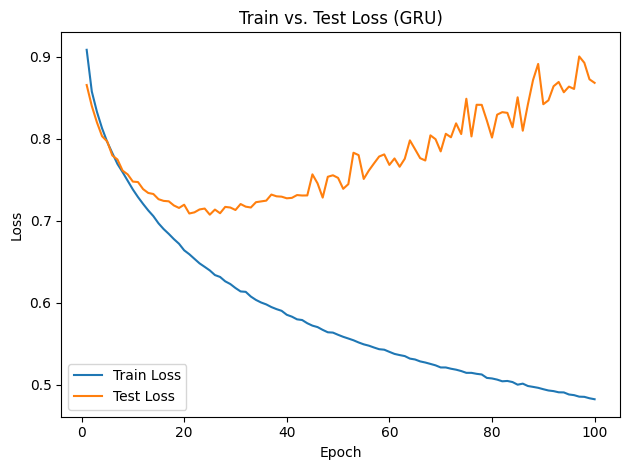

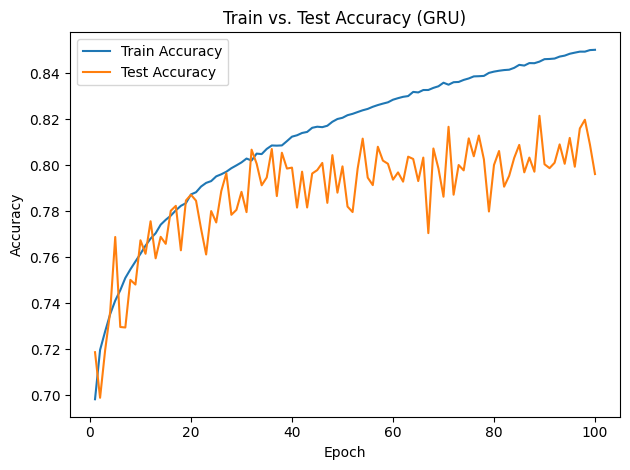

In [ ]:
epochs = np.arange(1, num_epochs + 1)

# Loss curves
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss (GRU)')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy curves
plt.figure()
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy (GRU)')
plt.legend()
plt.tight_layout()
plt.show()


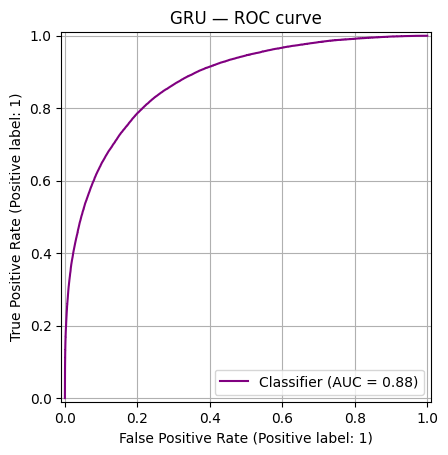

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_GRU, color = "Purple")
plt.title("GRU — ROC curve")
plt.grid(True); plt.show()

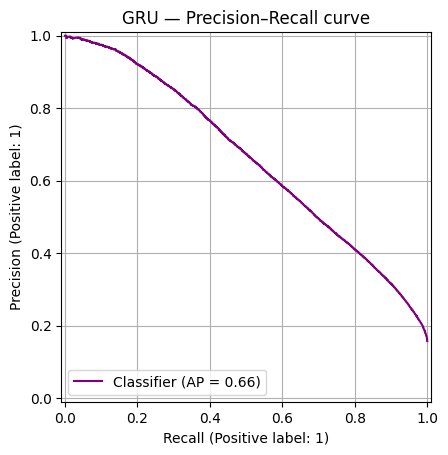

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

PrecisionRecallDisplay.from_predictions(all_labels, all_probs_GRU, color = "Purple")
plt.title("GRU — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for GRU')

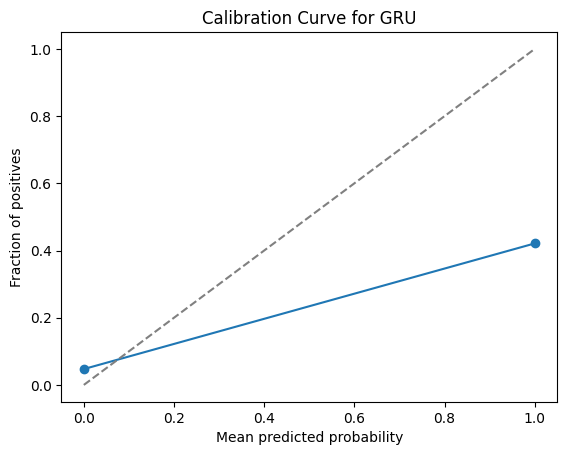

In [ ]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_GRU, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for GRU')

Text(0.5, 1.0, 'Normalized Confustion Matrix for GRU')

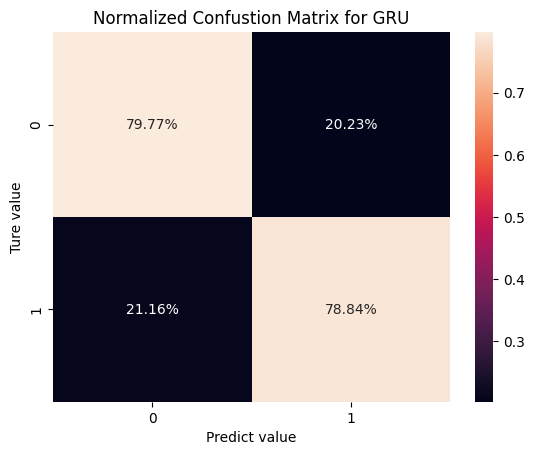

In [ ]:
from sklearn.metrics import confusion_matrix

CM_GRU = confusion_matrix(all_labels, all_preds_GRU, normalize = 'true')
sns.heatmap(CM_GRU, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for GRU")

# **GRU - Fine Tune**

In [ ]:
import torch
import torch.nn as nn
from sklearn.model_selection import ParameterGrid
from sklearn.metrics         import roc_auc_score


class GRUModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim = 1 ):
    super().__init__()
    self.input_dim = input_dim
    self.hidden_size = hidden_dim
    self.num_layers  = num_layers
    self.GRU = nn.GRU(input_dim, hidden_dim, num_layers, dropout = dropout, batch_first=True )
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self,x):
        out, _ = self.GRU(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

def train_and_evaluate(hidden_dim, num_layers, lr, dropout):

    model = GRUModel(
        input_dim=X_seq.shape[2],
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor([negatives / positives]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight= pos_weight)


    for epoch in range(3):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float().unsqueeze(-1)
            preds  = model(xb)
            loss   = criterion(preds, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()


    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb).cpu())
            all_probs .extend(probs.numpy())
            all_labels.extend(yb.numpy())
    return roc_auc_score(all_labels, all_probs)

param_grid = {
  "hidden_dim": [64, 128, 256, 512],
  "num_layers": [3, 4, 5, 6],
  "lr":         [1e-2, 1e-3],
  "dropout" :   [0.1, 0.2, 0.3]
}


best_score = 0.0
best_params = None
for params in ParameterGrid(param_grid):
    auc = train_and_evaluate(**params)
    print(f"{params} → AUC={auc:.4f}")
    if auc > best_score:
        best_score, best_params = auc, params

print("Best:", best_params, "→", best_score)

{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 3} → AUC=0.8247
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 4} → AUC=0.8138
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 5} → AUC=0.7971
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.01, 'num_layers': 6} → AUC=0.7853
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 3} → AUC=0.8426
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 4} → AUC=0.8412
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 5} → AUC=0.8421
{'dropout': 0.1, 'hidden_dim': 64, 'lr': 0.001, 'num_layers': 6} → AUC=0.8398
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 3} → AUC=0.8143
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 4} → AUC=0.8036
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 5} → AUC=0.7832
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.01, 'num_layers': 6} → AUC=0.7699
{'dropout': 0.1, 'hidden_dim': 128, 'lr': 0.001, 'num_layers': 3} → 

In [32]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim=1):
        super().__init__()
        self.GRU = nn.GRU(
            input_dim, hidden_dim, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.GRU(x)      # [B, T, H]
        out = out[:, -1, :]       # [B, H]
        return self.fc(out)       # [B, 1]

input_dim  = X_train.shape[2]
hidden_dim = 256
num_layers = 5
dropout    = 0.1

model = GRUModel(input_dim, hidden_dim, num_layers, dropout).to(device)

pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=2e-4)

num_epochs = 100

# ---- Trackers ----
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, num_epochs + 1):
    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float().unsqueeze(-1)  # [B,1]

        logits = model(x)
        loss   = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs

        with torch.no_grad():
            probs       = torch.sigmoid(logits)
            batch_preds = (probs > 0.5).float()
            running_correct += (batch_preds.int() == y.int()).sum().item()
            total_samples   += bs

    avg_train_loss = running_loss / total_samples
    train_acc      = running_correct / total_samples

    # ---------- TEST / EVAL ----------
    model.eval()
    test_running_loss = 0.0
    test_running_correct = 0
    test_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float().unsqueeze(-1)  # [B,1]

            logits = model(xb)
            loss   = criterion(logits, yb)

            bs = xb.size(0)
            test_running_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            test_running_correct += (preds.int() == yb.int()).sum().item()
            test_total += bs

    avg_test_loss = test_running_loss / test_total
    test_acc      = test_running_correct / test_total

    # ---- Store for plots ----
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {avg_test_loss:.4f} Acc: {test_acc:.3f}")

# ---------- Final test metrics (Accuracy & AUC) ----------
model.eval()
all_preds_GRU, all_probs_GRU, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb).cpu()                       # [B,1]
        probs_GRU  = torch.sigmoid(logits).numpy().ravel()
        preds_GRU  = (probs_GRU > 0.5).astype(np.int32)
        all_probs_GRU.extend(probs_GRU)
        all_preds_GRU.extend(preds_GRU)
        all_labels.extend(yb.cpu().numpy().ravel())

acc = accuracy_score(all_labels, all_preds_GRU)
auc = roc_auc_score(all_labels, all_probs_GRU)
print(f"Test — Accuracy: {acc:.4f} | AUC: {auc:.4f}")

Epoch   1 | Train Loss: 0.9145 Acc: 0.692 | Test Loss: 0.8633 Acc: 0.702
Epoch   2 | Train Loss: 0.8512 Acc: 0.726 | Test Loss: 0.8313 Acc: 0.725
Epoch   3 | Train Loss: 0.8238 Acc: 0.736 | Test Loss: 0.8131 Acc: 0.748
Epoch   4 | Train Loss: 0.8024 Acc: 0.744 | Test Loss: 0.7942 Acc: 0.750
Epoch   5 | Train Loss: 0.7849 Acc: 0.750 | Test Loss: 0.7805 Acc: 0.756
Epoch   6 | Train Loss: 0.7710 Acc: 0.755 | Test Loss: 0.7703 Acc: 0.766
Epoch   7 | Train Loss: 0.7574 Acc: 0.760 | Test Loss: 0.7603 Acc: 0.754
Epoch   8 | Train Loss: 0.7470 Acc: 0.763 | Test Loss: 0.7590 Acc: 0.748
Epoch   9 | Train Loss: 0.7374 Acc: 0.767 | Test Loss: 0.7480 Acc: 0.762
Epoch  10 | Train Loss: 0.7283 Acc: 0.769 | Test Loss: 0.7506 Acc: 0.766
Epoch  11 | Train Loss: 0.7198 Acc: 0.771 | Test Loss: 0.7414 Acc: 0.756
Epoch  12 | Train Loss: 0.7136 Acc: 0.774 | Test Loss: 0.7380 Acc: 0.775
Epoch  13 | Train Loss: 0.7056 Acc: 0.777 | Test Loss: 0.7339 Acc: 0.764
Epoch  14 | Train Loss: 0.6998 Acc: 0.777 | Test Lo

In [33]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_GRU = classification_report(all_labels, all_preds_GRU, digits=4)
print(report_GRU)


              precision    recall  f1-score   support

         0.0     0.9557    0.8066    0.8749    183536
         1.0     0.4357    0.7998    0.5641     34270

    accuracy                         0.8055    217806
   macro avg     0.6957    0.8032    0.7195    217806
weighted avg     0.8739    0.8055    0.8260    217806



In [34]:
from sklearn.metrics import cohen_kappa_score

kappa_GRU = cohen_kappa_score(all_labels, all_preds_GRU)
print(f"Cohen’s kappa: {kappa_GRU:.3f}")

Cohen’s kappa: 0.453


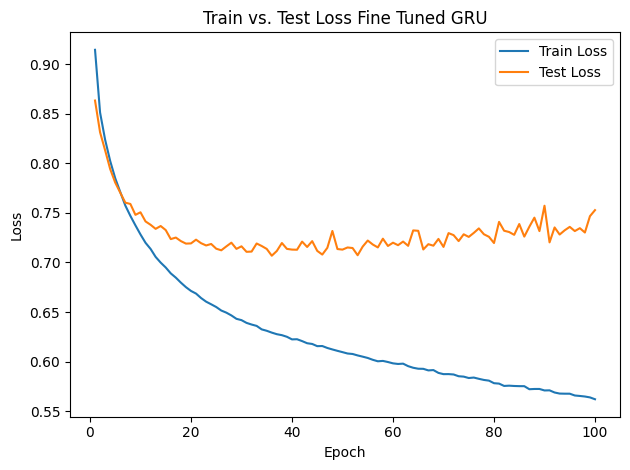

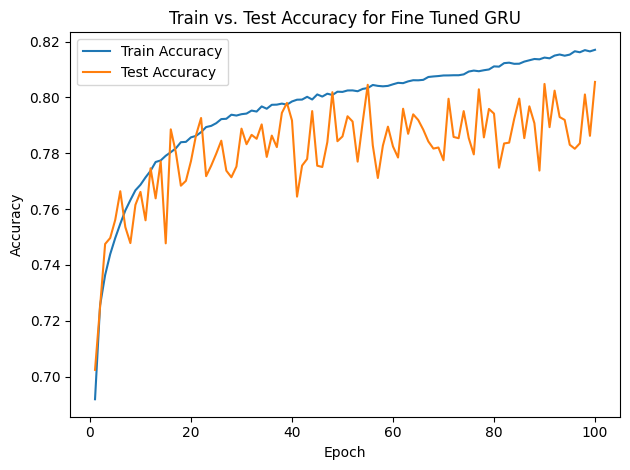

In [35]:
epochs = np.arange(1, num_epochs + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss Fine Tuned GRU')
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy for Fine Tuned GRU')
plt.legend()
plt.tight_layout()
plt.show()


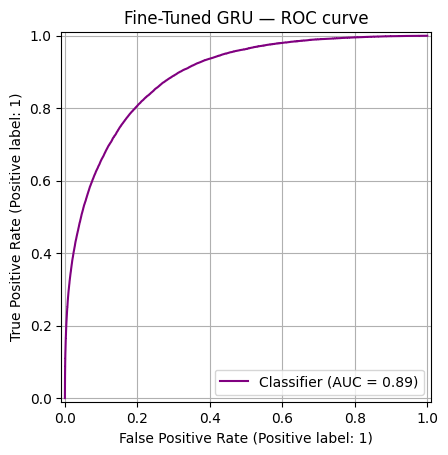

In [36]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_GRU, color = "Purple")
plt.title("Fine-Tuned GRU — ROC curve")
plt.grid(True); plt.show()

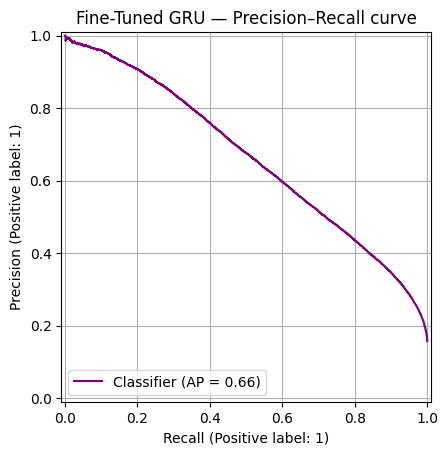

In [37]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_GRU, color = "Purple")
plt.title("Fine-Tuned GRU — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for GRU')

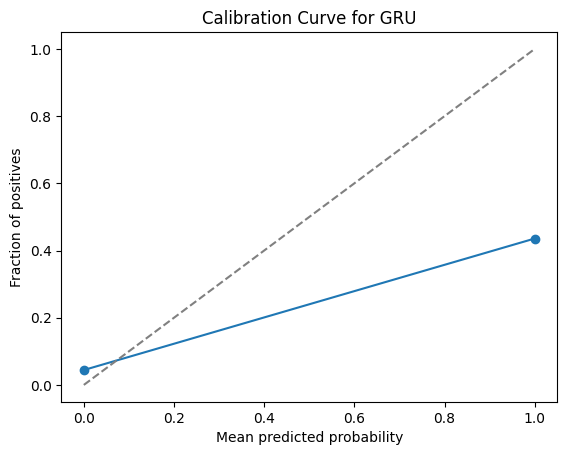

In [38]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_GRU, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for GRU')

Text(0.5, 1.0, 'Normalized Confustion Matrix for Fine Tuned GRU')

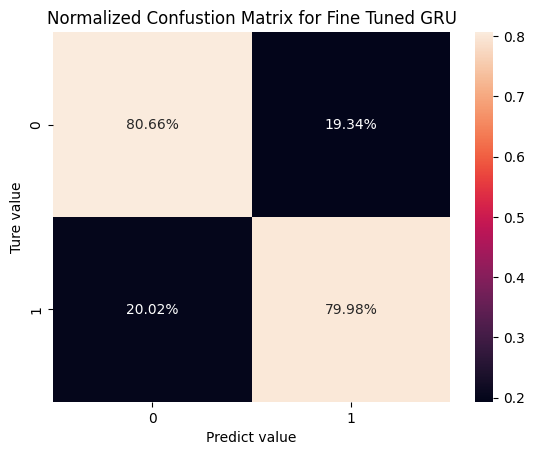

In [39]:
from sklearn.metrics import confusion_matrix

CM_GRU = confusion_matrix(all_labels, all_preds_GRU, normalize = 'true')
sns.heatmap(CM_GRU, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for Fine Tuned GRU")

# **Transformer**

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from torch.nn import CrossEntropyLoss

# ==== Core Transformer Components ==== #

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.w_q(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.w_k(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.w_v(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1,2).contiguous().view(B, T, -1)
        return self.w_o(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        # register as buffer so it moves with .to(device) and is saved in state_dict
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(y))
        z = self.ff(x)
        return self.norm2(x + self.dropout(z))

class MimicDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TabularEncoder(nn.Module):
    def __init__(self, feature_dim, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.proj    = nn.Linear(feature_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class MortalityPredictor(nn.Module):
    def __init__(self, encoder, d_model, dropout):
        super().__init__()
        self.encoder    = encoder
        self.pooler     = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, mask=None):
        h = self.encoder(x, mask)                 # [B, T, d_model]
        p = self.pooler(h.transpose(1,2)).squeeze(-1)  # [B, d_model]
        return self.classifier(p).squeeze(-1)     # [B]

# ==== Training & Final Test ==== #
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Assume train_loader, test_loader, X_train are defined externally
seq_len     = X_train.shape[1]
feature_dim = X_train.shape[2]

# Hyperparameters
hparams = {
    'd_model': 128,
    'num_heads': 2,
    'num_layers': 4,
    'd_ff': 512,
    'dropout': 0.1,
    'lr': 1e-3,
    'epochs': 100
}

encoder = TabularEncoder(
    feature_dim,
    hparams['d_model'],
    hparams['num_layers'],
    hparams['num_heads'],
    hparams['d_ff'],
    max_len=seq_len
)

model     = MortalityPredictor(encoder, hparams['d_model'], hparams['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hparams['lr'], weight_decay=1e-5)

# class imbalance
pos_weight = torch.tensor([2077431 / 380775], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

for epoch in range(1, hparams['epochs']+1):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()   # shape [B]

        optimizer.zero_grad()
        logits = model(X)                              # [B]
        loss = criterion(logits, y)                    # BCEWithLogitsLoss
        loss.backward()
        # optional: gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = X.size(0)
        running_loss += loss.item() * bs
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).int()
            correct += (preds == y.int()).sum().item()
            total += bs

    avg_train_loss = running_loss / total
    train_acc = correct / total

    # ===== TEST / EVAL =====
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).float()

            logits = model(X)
            loss = criterion(logits, y)

            bs = X.size(0)
            test_loss += loss.item() * bs

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()
            test_correct += (preds == y.int()).sum().item()
            test_total += bs

    avg_test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    print(f"Epoch {epoch:03d} | "
          f"Train Loss {avg_train_loss:.4f} Acc {train_acc:.3f} | "
          f"Test Loss {avg_test_loss:.4f} Acc {test_acc:.3f}")

# ===== Final test evaluation (kept) =====
model.eval()
test_loss = 0.0
all_probs_T, all_preds_T, all_labels = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()
        logits = model(X)
        loss = criterion(logits, y)
        test_loss += loss.item() * X.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()
        all_probs_T.append(probs.cpu())
        all_preds_T.append(preds.cpu())
        all_labels.append(y.cpu())

N = len(test_loader.dataset)
all_probs_T  = torch.cat(all_probs_T).numpy()
all_preds_T  = torch.cat(all_preds_T).numpy()
all_labels   = torch.cat(all_labels).numpy()
print(f"Test Loss={test_loss/N:.4f} | Test Acc={accuracy_score(all_labels, all_preds_T):.4f} | Test AUC={roc_auc_score(all_labels, all_probs_T):.4f}")


Epoch 001 | Train Loss 0.9254 Acc 0.685 | Test Loss 0.8609 Acc 0.685
Epoch 002 | Train Loss 0.8227 Acc 0.734 | Test Loss 0.7936 Acc 0.732
Epoch 003 | Train Loss 0.7603 Acc 0.760 | Test Loss 0.7337 Acc 0.756
Epoch 004 | Train Loss 0.7059 Acc 0.784 | Test Loss 0.6841 Acc 0.816
Epoch 005 | Train Loss 0.6583 Acc 0.802 | Test Loss 0.6378 Acc 0.805
Epoch 006 | Train Loss 0.6166 Acc 0.817 | Test Loss 0.6057 Acc 0.837
Epoch 007 | Train Loss 0.5809 Acc 0.830 | Test Loss 0.5852 Acc 0.836
Epoch 008 | Train Loss 0.5522 Acc 0.840 | Test Loss 0.5507 Acc 0.849
Epoch 009 | Train Loss 0.5236 Acc 0.851 | Test Loss 0.5226 Acc 0.851
Epoch 010 | Train Loss 0.5002 Acc 0.858 | Test Loss 0.5089 Acc 0.877
Epoch 011 | Train Loss 0.4804 Acc 0.865 | Test Loss 0.4993 Acc 0.846
Epoch 012 | Train Loss 0.4620 Acc 0.870 | Test Loss 0.4772 Acc 0.860
Epoch 013 | Train Loss 0.4449 Acc 0.877 | Test Loss 0.4680 Acc 0.861
Epoch 014 | Train Loss 0.4297 Acc 0.882 | Test Loss 0.4527 Acc 0.885
Epoch 015 | Train Loss 0.4171 Acc 

In [ ]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_transformer = classification_report(all_labels, all_preds_T, digits=4)
print(report_transformer)

              precision    recall  f1-score   support

         0.0     0.9827    0.9361    0.9588    183536
         1.0     0.7270    0.9120    0.8091     34270

    accuracy                         0.9323    217806
   macro avg     0.8549    0.9240    0.8840    217806
weighted avg     0.9425    0.9323    0.9353    217806



In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa_T = cohen_kappa_score(all_labels, all_preds_T)
print(f"Cohen’s kappa: {kappa_T:.3f}")

Cohen’s kappa: 0.769


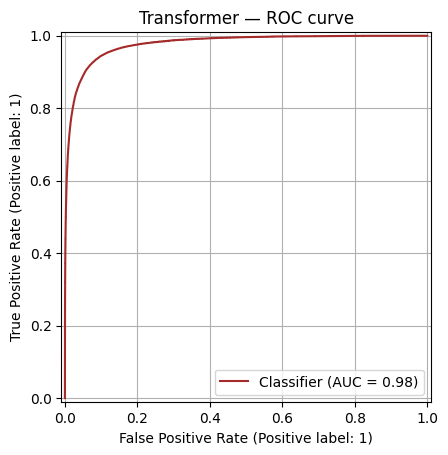

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_T, color = "Brown")
plt.title("Transformer — ROC curve")
plt.grid(True); plt.show()

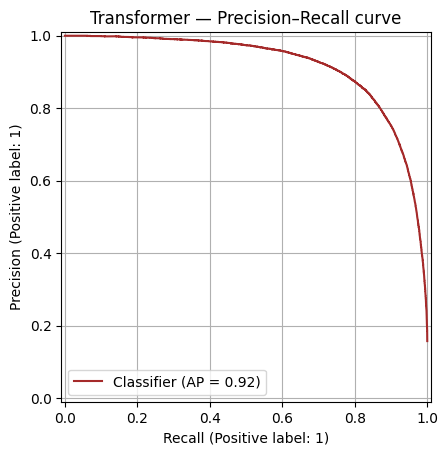

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_T, color = "Brown")
plt.title("Transformer — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for Transformer')

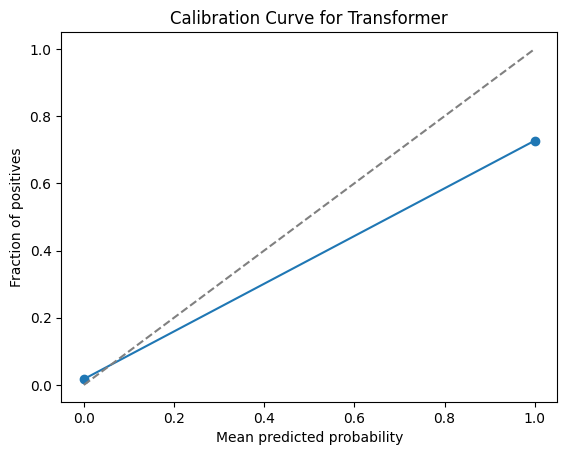

In [ ]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_T, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for Transformer')

Text(0.5, 1.0, 'Normalized Confustion Matrix for Tranformer')

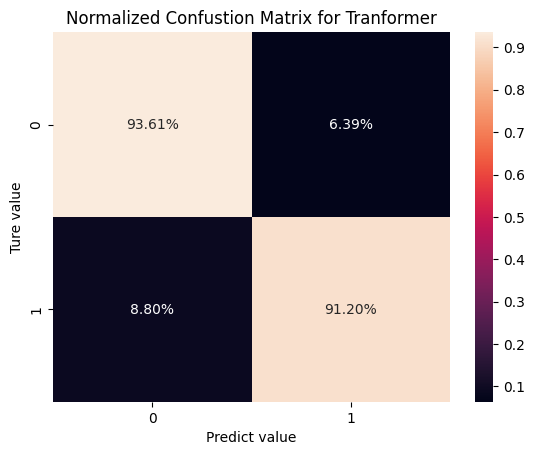

In [ ]:
from sklearn.metrics import confusion_matrix

CM_T = confusion_matrix(all_labels, all_preds_T, normalize = 'true')
sns.heatmap(CM_T, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for Tranformer")

# **Transformer - Fine Tune**

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from itertools import product
from copy import deepcopy

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.w_q(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.w_k(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.w_v(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1,2).contiguous().view(B, T, -1)
        return self.w_o(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :].to(x.device)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(y))
        z = self.ff(x)
        return self.norm2(x + self.dropout(z))

class MimicDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TabularEncoder(nn.Module):
    def __init__(self, feature_dim, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.proj    = nn.Linear(feature_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class MortalityPredictor(nn.Module):
    def __init__(self, encoder, d_model, dropout):
        super().__init__()
        self.encoder    = encoder
        self.pooler     = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, mask=None):
        h = self.encoder(x, mask)
        p = self.pooler(h.transpose(1,2)).squeeze(-1)
        return self.classifier(p).squeeze(-1)

seq_len     = X_train.shape[1]
feature_dim = X_train.shape[2]

param_grid = {
    'd_model':   [128, 256],
    'num_heads': [2, 4, 8],
    'num_layers': [2, 4, 6],
    'd_ff':      [256, 512],
    'dropout':   [0.1, 0.2],
    'lr':        [1e-2, 1e-3]
}
param_list = list(product(
    param_grid['d_model'],
    param_grid['num_heads'],
    param_grid['num_layers'],
    param_grid['d_ff'],
    param_grid['dropout'],
    param_grid['lr']
))

pos_weight = torch.tensor([negatives / positives]).to(device)

best_auc = 0.0
best_params = None
results = []

for i, (d_model, num_heads, num_layers, d_ff, dropout, lr) in enumerate(param_list):
    print(f"\nGrid {i+1}/{len(param_list)}: d_model={d_model}, num_heads={num_heads}, num_layers={num_layers}, d_ff={d_ff}, dropout={dropout}, lr={lr}")

    encoder = TabularEncoder(feature_dim, d_model, num_layers, num_heads, d_ff, max_len=seq_len)
    model = MortalityPredictor(encoder, d_model, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for epoch in range(1, 2):
        model.train()
        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device).float()
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_probs_T, all_labels = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device).float()
            logits = model(X)
            probs = torch.sigmoid(logits)
            all_probs_T.append(probs.cpu())
            all_labels.append(y.cpu())
    all_probs_T = torch.cat(all_probs_T).numpy()
    all_labels = torch.cat(all_labels).numpy()
    auc = roc_auc_score(all_labels, all_probs_T)
    print(f"Validation/Test AUC: {auc:.4f}")

    results.append(((d_model, num_heads, num_layers, d_ff, dropout, lr), auc))
    if auc > best_auc:
        best_auc = auc
        best_params = (d_model, num_heads, num_layers, d_ff, dropout, lr)
        best_model = deepcopy(model.state_dict())

print("\n=== Grid Search Results ===")
for params, auc in results:
    print(f"Params: {params}, AUC: {auc:.4f}")

print(f"\nBest Params: {best_params}, Best AUC: {best_auc:.4f}")



Grid 1/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.1, lr=0.01
Validation/Test AUC: 0.5495

Grid 2/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.1, lr=0.001
Validation/Test AUC: 0.8351

Grid 3/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.2, lr=0.01
Validation/Test AUC: 0.5047

Grid 4/144: d_model=128, num_heads=2, num_layers=2, d_ff=256, dropout=0.2, lr=0.001
Validation/Test AUC: 0.8114

Grid 5/144: d_model=128, num_heads=2, num_layers=2, d_ff=512, dropout=0.1, lr=0.01
Validation/Test AUC: 0.4980

Grid 6/144: d_model=128, num_heads=2, num_layers=2, d_ff=512, dropout=0.1, lr=0.001
Validation/Test AUC: 0.8108

Grid 7/144: d_model=128, num_heads=2, num_layers=2, d_ff=512, dropout=0.2, lr=0.01
Validation/Test AUC: 0.4950

Grid 8/144: d_model=128, num_heads=2, num_layers=2, d_ff=512, dropout=0.2, lr=0.001
Validation/Test AUC: 0.8323

Grid 9/144: d_model=128, num_heads=2, num_layers=4, d_ff=256, dropout=0.1, lr=0.01
Validation/Test 

In [40]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score
from torch.nn import CrossEntropyLoss

# ==== Core Transformer Components ==== #

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.w_q(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = self.w_k(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = self.w_v(x).view(B, T, self.num_heads, self.d_k).transpose(1,2)
        attn_out, _ = scaled_dot_product_attention(Q, K, V, mask)
        attn_out = attn_out.transpose(1,2).contiguous().view(B, T, -1)
        return self.w_o(attn_out)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :].to(x.device)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(y))
        z = self.ff(x)
        return self.norm2(x + self.dropout(z))

class MimicDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class TabularEncoder(nn.Module):
    def __init__(self, feature_dim, d_model, num_layers, num_heads, d_ff, max_len):
        super().__init__()
        self.proj    = nn.Linear(feature_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout=0.1)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.proj(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class MortalityPredictor(nn.Module):
    def __init__(self, encoder, d_model, dropout):
        super().__init__()
        self.encoder    = encoder
        self.pooler     = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, mask=None):
        h = self.encoder(x, mask)
        p = self.pooler(h.transpose(1,2)).squeeze(-1)
        return self.classifier(p).squeeze(-1)

# ==== Training & Final Test ==== #
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Assume train_loader, test_loader, X_train are defined externally
seq_len     = X_train.shape[1]
feature_dim = X_train.shape[2]

# Hyperparameters
hparams = {
    'd_model': 128,
    'num_heads': 4,
    'num_layers': 2,
    'd_ff': 512,
    'dropout': 0.1,
    'lr': 1e-3,
    'epochs': 100
}

encoder = TabularEncoder(
    feature_dim,
    hparams['d_model'],
    hparams['num_layers'],
    hparams['num_heads'],
    hparams['d_ff'],
    max_len=seq_len
)

model     = MortalityPredictor(encoder, hparams['d_model'], hparams['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=hparams['lr'], weight_decay=1e-5)

pos_weight = torch.tensor([2077431 / 380775], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


for epoch in range(1, hparams['epochs']+1):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X, y in train_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad()
        logits = model(X)                  # [B]
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # optional stability
        optimizer.step()

        bs = X.size(0)
        running_loss += loss.item() * bs
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).int()
            correct += (preds == y.int()).sum().item()
            total += bs

    avg_train_loss = running_loss / total
    train_acc = correct / total

    # ===== TEST / EVAL =====
    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).float()

            logits = model(X)
            loss = criterion(logits, y)

            bs = X.size(0)
            test_loss_sum += loss.item() * bs
            preds = (torch.sigmoid(logits) > 0.5).int()
            test_correct += (preds == y.int()).sum().item()
            test_total += bs

    avg_test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total

    print(f"Epoch {epoch:03d} | "
          f"Train Loss {avg_train_loss:.4f} Acc {train_acc:.3f} | "
          f"Test Loss {avg_test_loss:.4f} Acc {test_acc:.3f}")

# ===== Final test evaluation (Loss/Acc/AUC) =====
model.eval()
test_loss = 0.0
all_probs_T, all_preds_T, all_labels = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()
        logits = model(X)
        loss = criterion(logits, y)
        test_loss += loss.item() * X.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()
        all_probs_T.append(probs.cpu())
        all_preds_T.append(preds.cpu())
        all_labels.append(y.cpu())

N = len(test_loader.dataset)
all_probs_T = torch.cat(all_probs_T).numpy()
all_preds_T = torch.cat(all_preds_T).numpy()
all_labels  = torch.cat(all_labels).numpy()
print(f"Loss={test_loss/N:.4f} - Test Acc={accuracy_score(all_labels, all_preds_T):.4f} - Test AUC={roc_auc_score(all_labels, all_probs_T):.4f}")


Epoch 001 | Train Loss 0.9138 Acc 0.693 | Test Loss 0.8581 Acc 0.713
Epoch 002 | Train Loss 0.8307 Acc 0.732 | Test Loss 0.8134 Acc 0.753
Epoch 003 | Train Loss 0.7745 Acc 0.756 | Test Loss 0.7386 Acc 0.766
Epoch 004 | Train Loss 0.7226 Acc 0.777 | Test Loss 0.6991 Acc 0.790
Epoch 005 | Train Loss 0.6792 Acc 0.794 | Test Loss 0.6774 Acc 0.828
Epoch 006 | Train Loss 0.6423 Acc 0.808 | Test Loss 0.6307 Acc 0.806
Epoch 007 | Train Loss 0.6111 Acc 0.820 | Test Loss 0.6023 Acc 0.831
Epoch 008 | Train Loss 0.5859 Acc 0.828 | Test Loss 0.5814 Acc 0.838
Epoch 009 | Train Loss 0.5628 Acc 0.837 | Test Loss 0.5681 Acc 0.841
Epoch 010 | Train Loss 0.5434 Acc 0.844 | Test Loss 0.5499 Acc 0.843
Epoch 011 | Train Loss 0.5257 Acc 0.850 | Test Loss 0.5331 Acc 0.851
Epoch 012 | Train Loss 0.5105 Acc 0.855 | Test Loss 0.5378 Acc 0.870
Epoch 013 | Train Loss 0.4961 Acc 0.859 | Test Loss 0.5330 Acc 0.880
Epoch 014 | Train Loss 0.4818 Acc 0.863 | Test Loss 0.5119 Acc 0.850
Epoch 015 | Train Loss 0.4696 Acc 

In [41]:
from sklearn.metrics import classification_report

# Suppose all_labels and all_preds are your true and predicted labels:
report_transformer = classification_report(all_labels, all_preds_T, digits=4)
print(report_transformer)

              precision    recall  f1-score   support

         0.0     0.9862    0.9358    0.9603    183536
         1.0     0.7299    0.9298    0.8178     34270

    accuracy                         0.9348    217806
   macro avg     0.8581    0.9328    0.8891    217806
weighted avg     0.9459    0.9348    0.9379    217806



In [42]:
from sklearn.metrics import cohen_kappa_score

kappa_T = cohen_kappa_score(all_labels, all_preds_T)
print(f"Cohen’s kappa for Fine Tuned Transformer: {kappa_T:.3f}")

Cohen’s kappa for Fine Tuned Transformer: 0.779


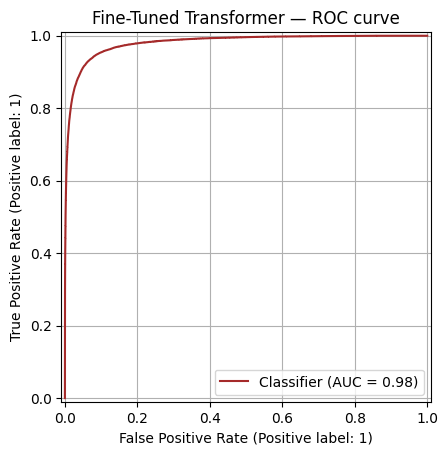

In [43]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)

RocCurveDisplay.from_predictions(all_labels, all_probs_T, color = "Brown")
plt.title("Fine-Tuned Transformer — ROC curve")
plt.grid(True); plt.show()

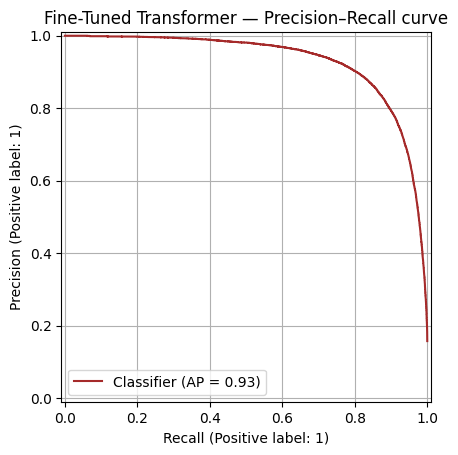

In [44]:
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score
)


# 3) Plot Precision–Recall curve + report Average Precision (area under PR)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs_T, color = "Brown")
plt.title("Fine-Tuned Transformer — Precision–Recall curve")
plt.grid(True); plt.show()

Text(0.5, 1.0, 'Calibration Curve for Fine Tuned Transformer')

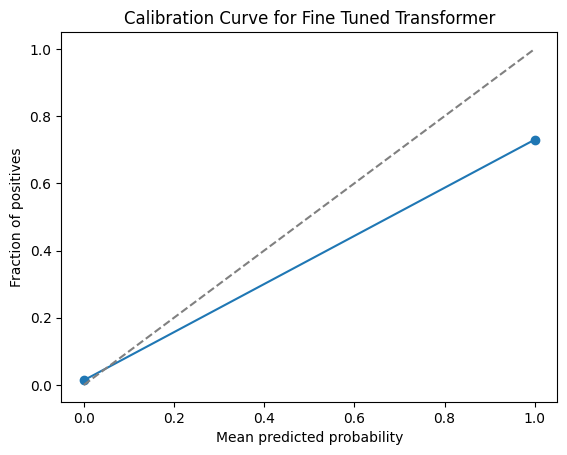

In [45]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(all_labels, all_preds_T, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve for Fine Tuned Transformer')

Text(0.5, 1.0, 'Normalized Confustion Matrix for Fine Tuned Tranformer')

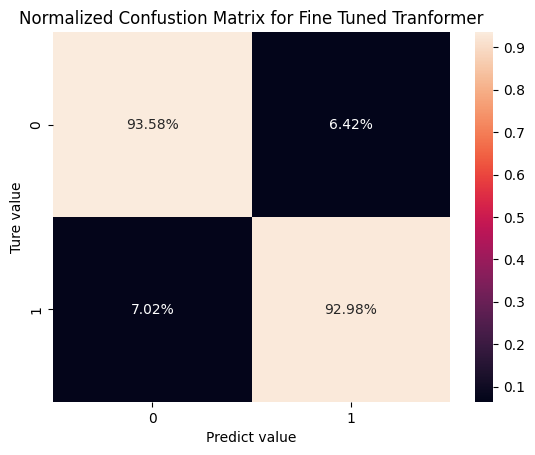

In [46]:
from sklearn.metrics import confusion_matrix

CM_T = confusion_matrix(all_labels, all_preds_T, normalize = 'true')
sns.heatmap(CM_T, annot= True, fmt = '.2%', cbar = True)
plt.xlabel("Predict value")
plt.ylabel("Ture value")
plt.title("Normalized Confustion Matrix for Fine Tuned Tranformer")